# MOE steel NPV simulation

Run the Monte Carlo simulation for molten oxide electrolysis steel and visualize its total NPV, LNM, and LCOS (steel LCOX) distributions. The NPV summary also reports the number and share of simulations with non-negative versus negative NPV.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from steel.steel_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_steel_results,
)

from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution


In [2]:
TECHNOLOGY = "moe"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_steel_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tcs,lifetime_years,capex_eur_per_tcs,fixed_opex_eur_per_tcs,variable_opex_eur_per_tcs,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tcs,present_value_total_cost_eur,lcos_eur_per_tcs,levelized_net_margin_eur_per_tcs
0,0,moe,absolute,not_applicable,1000000.0,20.0,1427.156008,62.768631,210.528574,none,...,2.647488e+08,0.0,0.0,5.380460e+08,2.119540e+08,6.538399e+08,9.818147e+06,6.709771e+09,683.404966,66.595034
1,1,moe,absolute,not_applicable,1000000.0,20.0,1369.219192,101.036842,316.142082,none,...,3.506935e+08,0.0,0.0,7.678724e+08,-1.787244e+07,-1.544693e+09,9.818147e+06,8.908304e+09,907.330442,-157.330442
2,2,moe,absolute,not_applicable,1000000.0,20.0,1322.234776,57.815393,162.564154,none,...,4.869702e+08,0.0,0.0,7.073498e+08,4.265023e+07,-9.034885e+08,9.818147e+06,8.267099e+09,842.022299,-92.022299
3,3,moe,absolute,not_applicable,1000000.0,20.0,825.370625,45.138672,203.092279,none,...,4.854114e+08,0.0,0.0,7.336423e+08,1.635768e+07,-6.647685e+08,9.818147e+06,8.028379e+09,817.708141,-67.708141
4,4,moe,absolute,not_applicable,1000000.0,20.0,788.644913,97.278892,236.335812,none,...,4.238778e+08,0.0,0.0,7.574925e+08,-7.492499e+06,-8.622074e+08,9.818147e+06,8.225818e+09,837.817726,-87.817726


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcos_eur_per_tcs = results["lcos_eur_per_tcs"]
levelized_net_margin_eur_per_tcs = results["levelized_net_margin_eur_per_tcs"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        lcos_eur_per_tcs.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "LCOS EUR/tCS"
        ),
        levelized_net_margin_eur_per_tcs.describe(
            percentiles=[0.05, 0.5, 0.95]
        ).rename("Levelized net margin EUR/tCS"),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,LCOS EUR/tCS,Levelized net margin EUR/tCS
count,100000.000000,100000.000000,100000.000000
mean,-1342.003716,886.686043,-136.686043
std,1210.905201,123.333369,123.333369
min,-5790.962383,486.713491,-589.822310
5%,-3364.006125,686.168869,-342.631454
50%,-1334.858483,885.958285,-135.958285
95%,626.703456,1092.631454,63.831131
max,2584.985760,1339.822310,263.286509


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),14346,0.14346
1,Negative (NPV < 0),85654,0.85654


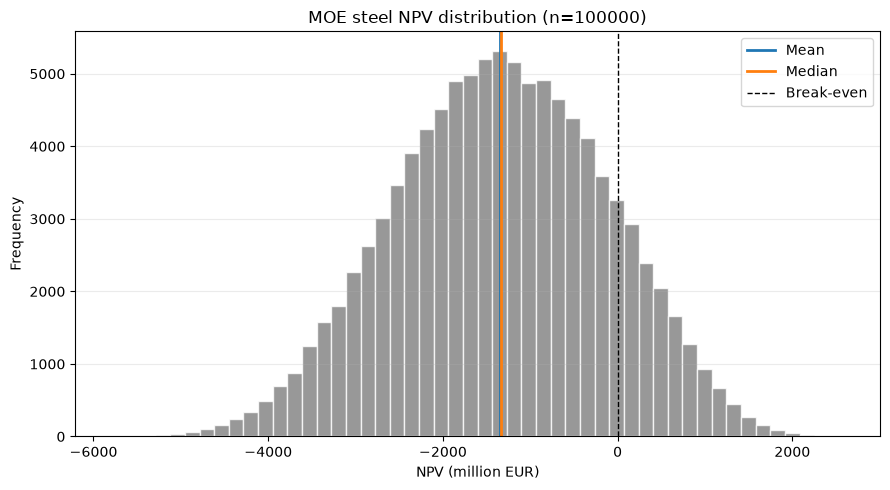

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"MOE steel NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()


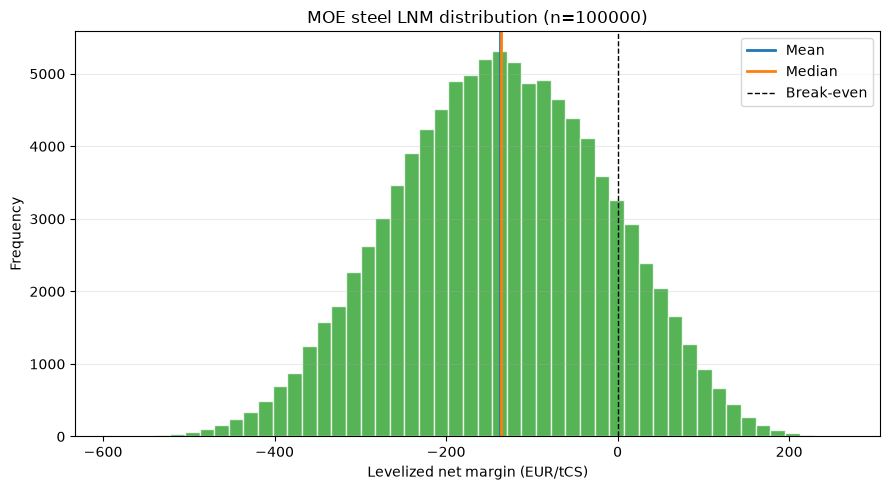

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tcs,
    title=f"MOE steel LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tCS)",
    color="tab:green",
    show_break_even=True,
)
plt.show()


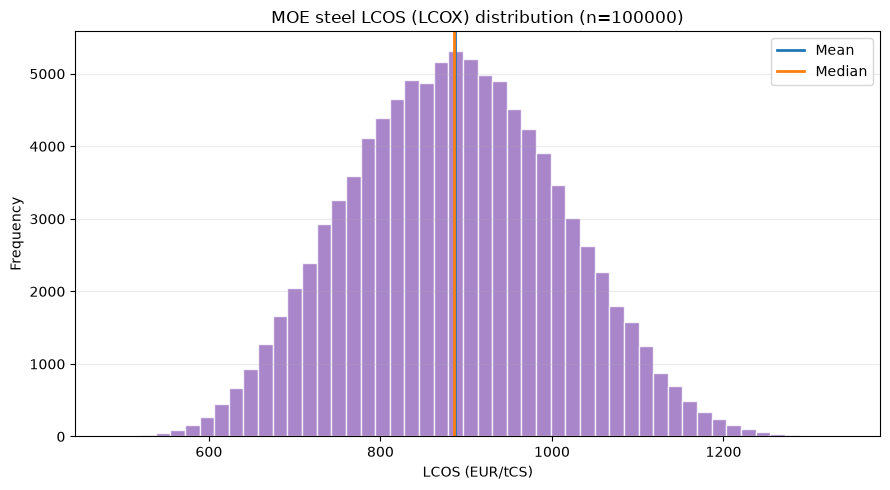

In [6]:
plot_financial_metric_distribution(
    lcos_eur_per_tcs,
    title=f"MOE steel LCOS (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOS (EUR/tCS)",
    color="tab:purple",
)
plt.show()


In [7]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur"
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             750.000000
annual_fixed_opex_eur           69.024271
annual_variable_opex_eur       246.099561
annual_fuel_cost_eur             0.000000
annual_electricity_cost_eur    452.731578
annual_emissions_cost_eur        0.000000
annual_net_cash_flow_eur       -17.855410
Name: Mean annual value, million EUR, dtype: float64